# TRABALHO FINAL INTEGRADOR - SEMANA 1
## Detecção de Fraude em Transações Financeiras
### Cenário 4: Detecção de Fraude ou Transações Financeiras Suspeitas

---

**Disciplina:** Tópicos Especiais 2 - Agrupamento de Dados e Inteligência Computacional  
**Professores:** Dr. Gustavo Prado e Dr. Clarimundo Machado  
**Data:** Semana 1 de 5

---

## 📋 Divisão de Papéis

| Aluno | Papel | Responsabilidades |
|-------|-------|-------------------|
| **Ruan** | Agrupamento de Dados | Implementação técnica em Python, detecção de outliers, clustering |
| **Lucio** | Dados, Pipeline e Integração | Análise exploratória, documentação, repositório, decisões de dados |
| **Artur** | Inteligência Computacional e Decisão | Modelagem preditiva, técnicas de IC, métricas e avaliação |

---

## 1️⃣ DESCRIÇÃO DO PROBLEMA E DA BASE DE DADOS

### Problema
Instituições financeiras precisam identificar transações suspeitas em bases **altamente desbalanceadas**, nas quais fraudes são extremamente raras (anomalias < 1% dos dados).

### Pergunta Central
**Como usar agrupamento para identificar padrões normais e anômalos e apoiar um modelo de detecção de fraude ou risco?**

### Base de Dados Utilizada
- **Nome:** Credit Card Fraud Detection
- **Fonte:** [Kaggle - MLG ULB Dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
- **Tamanho:** 284.807 transações
- **Fraudes:** 492 transações (0.173% - altamente desbalanceado)
- **Características:** Dados de cartão de crédito europeu, período de 2 dias em setembro de 2013
- **Variáveis:** 31 colunas (28 features PCA + Amount + Time + Class)

### Relevância do Problema
- Detecção em tempo real de fraude
- Proteção do cliente e instituição
- Desafio de desbalanceamento de classes
- Necessidade de alta precisão e recall

---

## 2️⃣ IMPORTAÇÕES E CONFIGURAÇÕES INICIAIS

In [1]:
# Importações básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configurações visuais
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Opções de display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print("✅ Ambiente configurado com sucesso!")
print(f"Timestamp: {datetime.now()}")

✅ Ambiente configurado com sucesso!
Timestamp: 2026-06-16 19:58:52.373214


## 3️⃣ CARREGAMENTO DA BASE DE DADOS

**Responsável:** Lucio (com apoio de Ruan)  
**Tarefa:** Carregar e documentar a origem dos dados

In [4]:
# TODO: Lucio e Ruan - Adaptar o caminho do arquivo conforme necessário
# Baixar em: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# Descompactar na pasta: dados/

# Carregamento da base
DATA_PATH = '../dados/creditcard.csv'

try:
    df = pd.read_csv(DATA_PATH)
    print("✅ Base carregada com sucesso!")
    print(f"   - Arquivo: {DATA_PATH}")
    print(f"   - Linhas: {df.shape[0]:,}")
    print(f"   - Colunas: {df.shape[1]}")
except FileNotFoundError:
    print(f"❌ Arquivo não encontrado. Verifique o caminho: {DATA_PATH}")
    print("   Baixe em: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud")

✅ Base carregada com sucesso!
   - Arquivo: ../dados/creditcard.csv
   - Linhas: 284,807
   - Colunas: 31


## 4️⃣ ANÁLISE EXPLORATÓRIA INICIAL (EDA)

**Responsável:** Ruan (Implementação técnica) + Lucio (Interpretação)  
**Tarefas:** Explorar estrutura, tipos de dados, distribuições e padrões iniciais

In [5]:
# 4.1 - Primeiras linhas
print("="*80)
print("PRIMEIRAS LINHAS DA BASE")
print("="*80)
display(df.head())

PRIMEIRAS LINHAS DA BASE


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [6]:
# 4.2 - Informações básicas
print("="*80)
print("INFORMAÇÕES GERAIS")
print("="*80)
print(f"\nForma: {df.shape}")
print(f"\nTipos de dados:")
print(df.dtypes)
print(f"\nMemória utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

INFORMAÇÕES GERAIS

Forma: (284807, 31)

Tipos de dados:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Memória utilizada: 67.36 MB


In [7]:
# 4.3 - Estatísticas descritivas
print("="*80)
print("ESTATÍSTICAS DESCRITIVAS")
print("="*80)
display(df.describe().T)

ESTATÍSTICAS DESCRITIVAS


,count,mean,std,min,25%,50%,75%,max
Time,284807.0000,94813.8596,47488.1460,0.0000,54201.5000,84692.0000,139320.5000,172792.0000
V1,284807.0000,0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,284807.0000,0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,284807.0000,-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,284807.0000,0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,284807.0000,0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,284807.0000,0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,284807.0000,-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,284807.0000,0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,284807.0000,-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


ANÁLISE DA VARIÁVEL ALVO (FRAUDE)

Distribuição:
  - Transações legítimas (0): 284,315 (99.83%)
  - Fraudes (1): 492 (0.17%)

⚠️  IMPORTANTE: Base ALTAMENTE DESBALANCEADA!
    Razão: 577.9 legítimas por 1 fraude


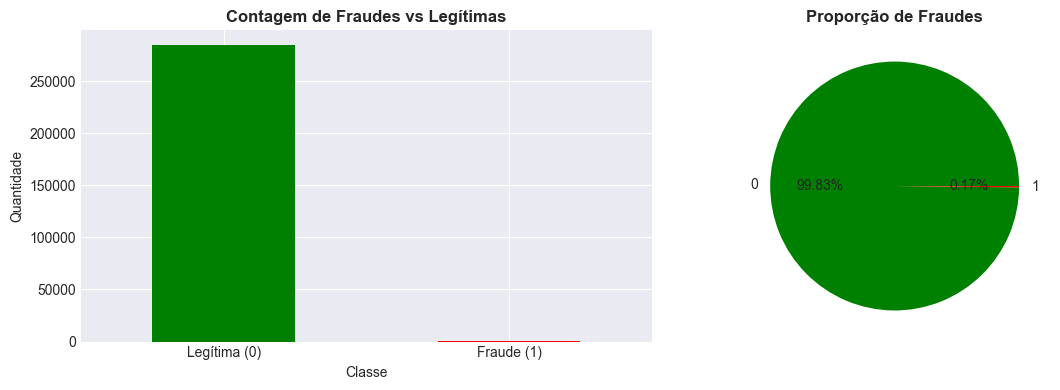

In [ ]:
# 4.4 - Análise da variável alvo (Class - Fraude)
print("="*80)
print("ANÁLISE DA VARIÁVEL ALVO (FRAUDE)")
print("="*80)

class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print(f"\nDistribuição:")
print(f"  - Transações legítimas (0): {class_counts[0]:,} ({class_pct[0]:.2f}%)")
print(f"  - Fraudes (1): {class_counts[1]:,} ({class_pct[1]:.2f}%)")
print(f"\n⚠️  IMPORTANTE: Base ALTAMENTE DESBALANCEADA!")
print(f"    Razão: {class_counts[0] / class_counts[1]:.1f} legítimas por 1 fraude")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Contagem de Fraudes vs Legítimas', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Quantidade')
axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'], rotation=0)

class_pct.plot(kind='pie', ax=axes[1], autopct='%1.2f%%', colors=['green', 'red'])
axes[1].set_title('Proporção de Fraudes', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

ANÁLISE DO VALOR DAS TRANSAÇÕES (AMOUNT)

Transações Legítimas:
count   284315.0000
mean        88.2910
std        250.1051
min          0.0000
25%          5.6500
50%         22.0000
75%         77.0500
max      25691.1600
Name: Amount, dtype: float64

Fraudes:
count    492.0000
mean     122.2113
std      256.6833
min        0.0000
25%        1.0000
50%        9.2500
75%      105.8900
max     2125.8700
Name: Amount, dtype: float64


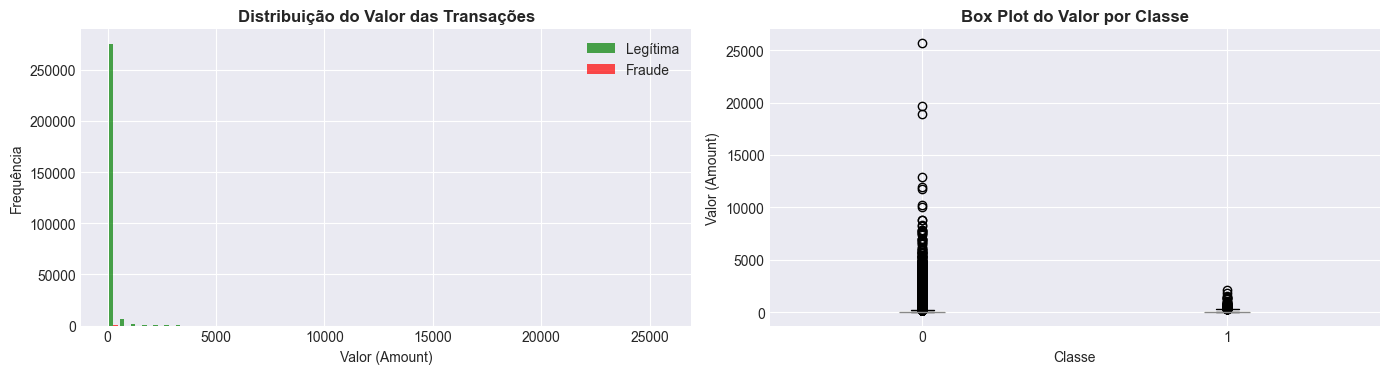

In [ ]:
# 4.5 - Análise da variável Amount (valor da transação)
print("="*80)
print("ANÁLISE DO VALOR DAS TRANSAÇÕES (AMOUNT)")
print("="*80)

print("\nTransações Legítimas:")
print(df[df['Class']==0]['Amount'].describe())

print("\nFraudes:")
print(df[df['Class']==1]['Amount'].describe())

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribuição
axes[0].hist([df[df['Class']==0]['Amount'], df[df['Class']==1]['Amount']], 
             label=['Legítima', 'Fraude'], bins=50, color=['green', 'red'], alpha=0.7)
axes[0].set_title('Distribuição do Valor das Transações', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valor (Amount)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Box plot
df.boxplot(column='Amount', by='Class', ax=axes[1])
axes[1].set_title('Box Plot do Valor por Classe', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Valor (Amount)')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 5️⃣ TRATAMENTO DE VALORES AUSENTES

**Responsável:** Ruan  
**Tarefa:** Identificar e tratar valores ausentes (NaN, None)

In [ ]:
# 5.1 - Identificar valores ausentes
print("="*80)
print("ANÁLISE DE VALORES AUSENTES")
print("="*80)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Coluna': missing.index,
    'Valores Ausentes': missing.values,
    'Percentual (%)': missing_pct.values
}).sort_values('Valores Ausentes', ascending=False)

print(f"\nTotal de colunas: {len(df.columns)}")
print(f"Colunas sem ausentes: {(missing == 0).sum()}")
print(f"Colunas com ausentes: {(missing > 0).sum()}")
print(f"\nDetalhes:\n")
display(missing_df[missing_df['Valores Ausentes'] > 0])

if missing.sum() == 0:
    print("\n✅ Excelente! Não há valores ausentes na base.")

ANÁLISE DE VALORES AUSENTES

Total de colunas: 31
Colunas sem ausentes: 31
Colunas com ausentes: 0

Detalhes:



,Coluna,Valores Ausentes,Percentual (%)



✅ Excelente! Não há valores ausentes na base.


## 6️⃣ TRATAMENTO DE DUPLICIDADES

**Responsável:** Ruan  
**Tarefa:** Identificar e remover registros duplicados

In [ ]:
# 6.1 - Análise de duplicidades
print("="*80)
print("ANÁLISE DE DUPLICIDADES")
print("="*80)

duplicados_total = df.duplicated().sum()
duplicados_partial = df.duplicated(subset=['Time', 'Amount']).sum()

print(f"\nLinhas completamente duplicadas: {duplicados_total}")
print(f"Linhas duplicadas (Time + Amount): {duplicados_partial}")

if duplicados_total > 0:
    print(f"\n⚠️  Removendo {duplicados_total} linhas duplicadas...")
    df = df.drop_duplicates()
    print(f"✅ Novo tamanho da base: {df.shape[0]:,} linhas")
else:
    print(f"\n✅ Nenhuma duplicidade encontrada.")

ANÁLISE DE DUPLICIDADES



Linhas completamente duplicadas: 1081
Linhas duplicadas (Time + Amount): 4863

⚠️  Removendo 1081 linhas duplicadas...


✅ Novo tamanho da base: 283,726 linhas

## 7️⃣ IDENTIFICAÇÃO DE OUTLIERS

**Responsável:** Ruan (Implementação) + Artur (Análise)  
**Tarefa:** Detectar anomalias e outliers (crítico para detecção de fraude!)

In [ ]:
# 7.1 - Método IQR (Interquartile Range)
print("="*80)
print("DETECÇÃO DE OUTLIERS - MÉTODO IQR")
print("="*80)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

# Aplicar a diferentes colunas
outlier_cols = ['Amount', 'Time']
outlier_summary = {}

for col in outlier_cols:
    outliers = detect_outliers_iqr(df, col)
    outlier_count = outliers.sum()
    outlier_pct = (outlier_count / len(df)) * 100
    outlier_summary[col] = {'count': outlier_count, 'pct': outlier_pct}
    print(f"\n{col}:")
    print(f"  - Outliers detectados: {outlier_count} ({outlier_pct:.2f}%)")

print("\n⚠️  IMPORTANTE: Outliers em Amount podem ser transações legítimas!")
print("    NÃO remover agora - importante para análise de fraude posterior.")

DETECÇÃO DE OUTLIERS - MÉTODO IQR

Amount:
  - Outliers detectados: 31685 (11.17%)

Time:
  - Outliers detectados: 0 (0.00%)

⚠️  IMPORTANTE: Outliers em Amount podem ser transações legítimas!
    NÃO remover agora - importante para análise de fraude posterior.


/var/folders/mp/svhcpdf94p34x40qrvs0czc40000gn/T/ipykernel_68994/2622236035.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data_to_plot, labels=['Legítima', 'Fraude'])


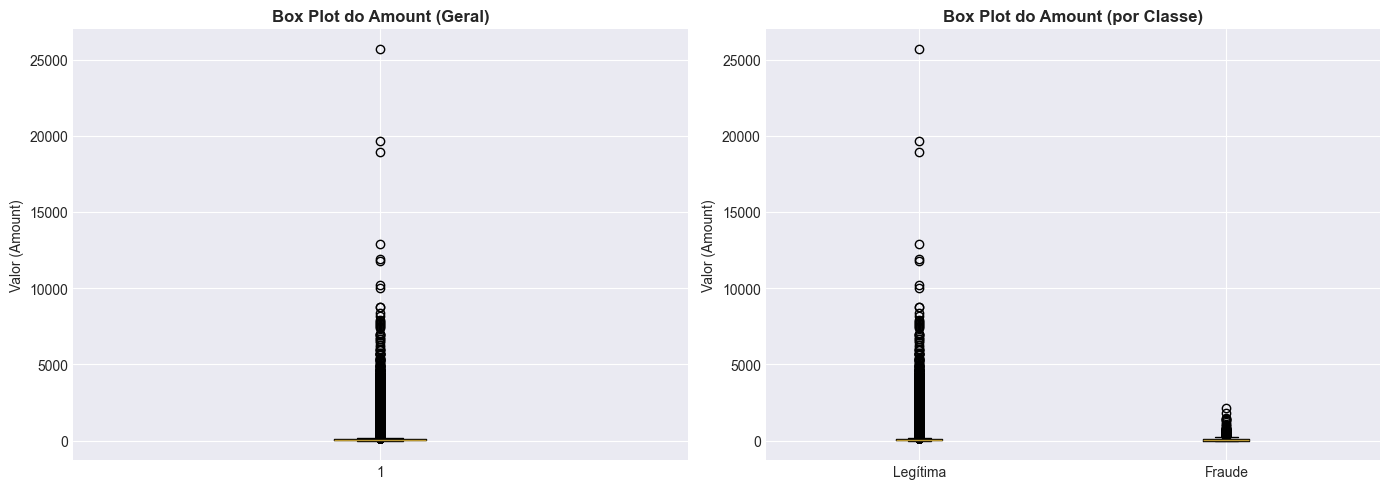

In [ ]:
# 7.2 - Visualização de outliers no Amount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot geral
bp = axes[0].boxplot(df['Amount'], vert=True)
axes[0].set_title('Box Plot do Amount (Geral)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valor (Amount)')

# Box plot por classe
data_to_plot = [df[df['Class']==0]['Amount'], df[df['Class']==1]['Amount']]
bp2 = axes[1].boxplot(data_to_plot, labels=['Legítima', 'Fraude'])
axes[1].set_title('Box Plot do Amount (por Classe)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Valor (Amount)')

plt.tight_layout()
plt.show()

## 8️⃣ TRANSFORMAÇÃO DE VARIÁVEIS CATEGÓRICAS

**Responsável:** Ruan  
**Tarefa:** Analisar e transformar variáveis categóricas (se houver)

In [ ]:
# 8.1 - Identificar variáveis categóricas
print("="*80)
print("ANÁLISE DE VARIÁVEIS CATEGÓRICAS")
print("="*80)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nVariáveis categóricas encontradas: {categorical_cols}")

if len(categorical_cols) == 0:
    print("✅ Nenhuma variável categórica encontrada.")
    print("   A base já está numérica (features foram transformadas por PCA).")
else:
    print("\nColunas categóricas e seus valores únicos:")
    for col in categorical_cols:
        print(f"  - {col}: {df[col].nunique()} valores únicos")
        print(f"    Valores: {df[col].unique()[:10]}")

ANÁLISE DE VARIÁVEIS CATEGÓRICAS

Variáveis categóricas encontradas: []
✅ Nenhuma variável categórica encontrada.
   A base já está numérica (features foram transformadas por PCA).


## 9️⃣ DESCRIÇÃO DOS ATRIBUTOS

**Responsável:** Lucio  
**Tarefa:** Documentar e descrever cada atributo

In [ ]:
print("="*80)
print("DESCRIÇÃO DOS ATRIBUTOS")
print("="*80)

attributes_description = """
ATRIBUTOS DA BASE:

1. Time (int)
   - Segundos decorridos entre esta transação e a primeira da base
   - Intervalo: 0 a 172792 segundos (~2 dias)

2. V1 a V28 (float)
   - Componentes principais resultados de transformação PCA
   - Mantidas por confidencialidade (não há interpretação direta)
   - Escaladas e normalizadas
   - Estas são as PRINCIPAIS FEATURES para análise

3. Amount (float)
   - Valor da transação em dólar
   - Intervalo: $0.00 a $25,691.16
   - NÃO foi transformado por PCA

4. Class (int) - VARIÁVEL ALVO
   - 0 = Transação legítima
   - 1 = Fraude
   - DESBALANCEADA: 99.83% legítimas, 0.17% fraudes
"""

print(attributes_description)

DESCRIÇÃO DOS ATRIBUTOS

ATRIBUTOS DA BASE:

1. Time (int)
   - Segundos decorridos entre esta transação e a primeira da base
   - Intervalo: 0 a 172792 segundos (~2 dias)

2. V1 a V28 (float)
   - Componentes principais resultados de transformação PCA
   - Mantidas por confidencialidade (não há interpretação direta)
   - Escaladas e normalizadas
   - Estas são as PRINCIPAIS FEATURES para análise

3. Amount (float)
   - Valor da transação em dólar
   - Intervalo: $0.00 a $25,691.16
   - NÃO foi transformado por PCA

4. Class (int) - VARIÁVEL ALVO
   - 0 = Transação legítima
   - 1 = Fraude
   - DESBALANCEADA: 99.83% legítimas, 0.17% fraudes



## 🔟 CORRELAÇÕES E PADRÕES

**Responsável:** Ruan (Implementação) + Lucio (Análise)  
**Tarefa:** Explorar correlações entre variáveis

CORRELAÇÃO COM FRAUDE (Class)



Top 15 features mais correlacionadas com fraude:
Class     1.0000
V11       0.1491
V4        0.1293
V2        0.0846
V19       0.0336
V8        0.0331
V21       0.0264
V27       0.0219
V20       0.0215
V28       0.0097
Amount    0.0058
V22       0.0049
V26       0.0043
V25       0.0032
V15      -0.0033
Name: Class, dtype: float64


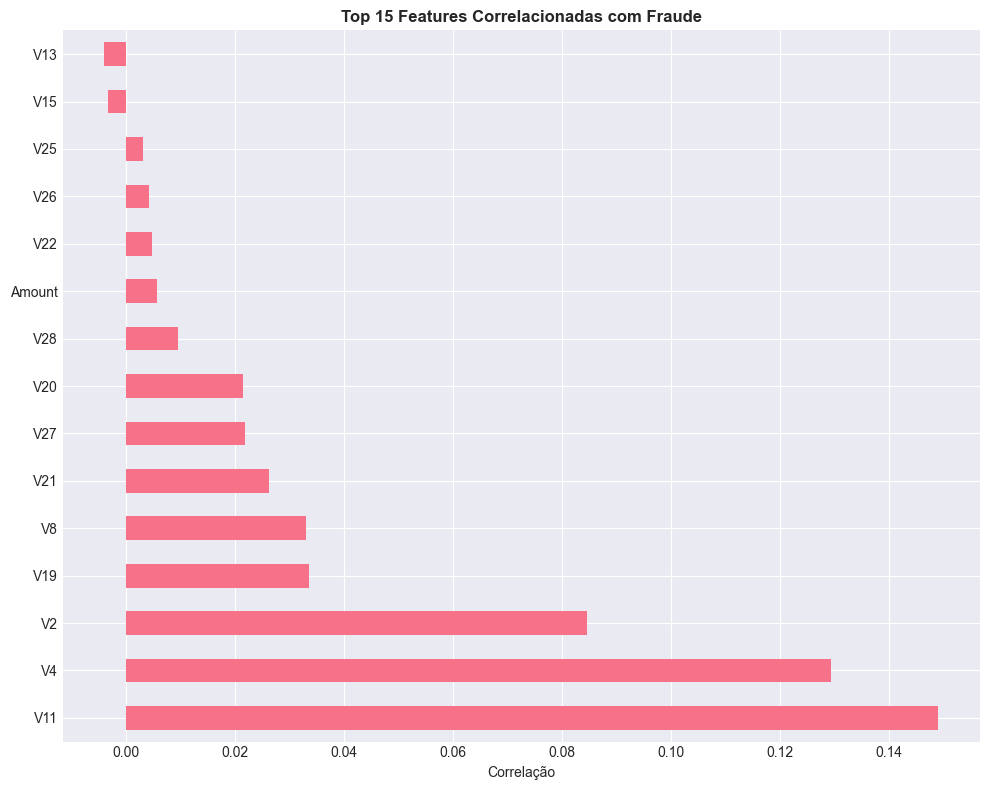

In [ ]:
# 10.1 - Correlação com a variável alvo
print("="*80)
print("CORRELAÇÃO COM FRAUDE (Class)")
print("="*80)

correlation_with_class = df.corr()['Class'].sort_values(ascending=False)
print("\nTop 15 features mais correlacionadas com fraude:")
print(correlation_with_class.head(15))

# Visualização
plt.figure(figsize=(10, 8))
correlation_with_class[1:16].plot(kind='barh')
plt.title('Top 15 Features Correlacionadas com Fraude', fontsize=12, fontweight='bold')
plt.xlabel('Correlação')
plt.tight_layout()
plt.show()


MATRIZ DE CORRELAÇÃO - TOP FEATURES


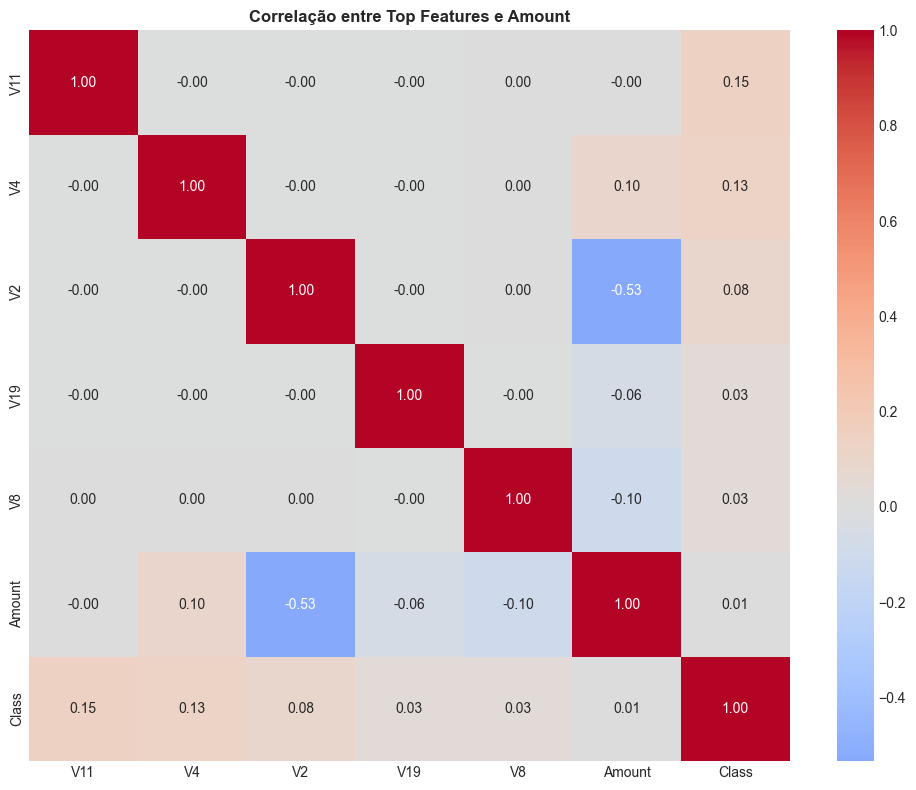

In [ ]:
# 10.2 - Matriz de correlação (amostra)
print("\n" + "="*80)
print("MATRIZ DE CORRELAÇÃO - TOP FEATURES")
print("="*80)

top_features = correlation_with_class[1:6].index.tolist() + ['Amount', 'Class']
corr_matrix = df[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre Top Features e Amount', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 1️⃣1️⃣ STATUS FINAL E PRÓXIMAS ETAPAS

**Responsável:** Lucio (Coordenação) + Ruan (Técnico)

In [ ]:
print("="*80)
print("RESUMO DA SEMANA 1")
print("="*80)

print(f"\n✅ STATUS ATUAL:")
print(f"   - Linhas na base: {df.shape[0]:,}")
print(f"   - Colunas: {df.shape[1]}")
print(f"   - Valores ausentes: {df.isnull().sum().sum()}")
print(f"   - Linhas duplicadas removidas: {duplicados_total}")
print(f"   - Outliers identificados: SIM (não removidos)")
print(f"   - Variáveis categóricas: {len(categorical_cols)}")

print(f"\n📊 CARACTERÍSTICAS IMPORTANTES:")
print(f"   - Base ALTAMENTE DESBALANCEADA: {class_pct[1]:.2f}% fraudes")
print(f"   - Features: 28 componentes PCA + Amount + Time")
print(f"   - Período: ~2 dias (setembro de 2013)")
print(f"   - Valores de transações: ${df['Amount'].min():.2f} a ${df['Amount'].max():.2f}")

print(f"\n🎯 PRÓXIMAS ETAPAS (SEMANA 2-3):")
print(f"   - Normalização/Padronização das features")
print(f"   - Aplicar K-Means")
print(f"   - Aplicar DBSCAN (melhor para anomalias)")
print(f"   - Avaliar clusters com métricas (Silhouette, Davies-Bouldin)")
print(f"   - Interpretar padrões de fraude encontrados")

print(f"\n👥 DIVISÃO DE TRABALHO:")
print(f"   - Ruan: Implementação técnica do preprocessing")
print(f"   - Lucio: Documentação e análise de negócio")
print(f"   - Artur: Planejamento de técnicas de IC e métricas")

RESUMO DA SEMANA 1

✅ STATUS ATUAL:
   - Linhas na base: 283,726
   - Colunas: 31
   - Valores ausentes: 0
   - Linhas duplicadas removidas: 1081
   - Outliers identificados: SIM (não removidos)
   - Variáveis categóricas: 0

📊 CARACTERÍSTICAS IMPORTANTES:
   - Base ALTAMENTE DESBALANCEADA: 0.17% fraudes
   - Features: 28 componentes PCA + Amount + Time
   - Período: ~2 dias (setembro de 2013)
   - Valores de transações: $0.00 a $25691.16

🎯 PRÓXIMAS ETAPAS (SEMANA 2-3):
   - Normalização/Padronização das features
   - Aplicar K-Means
   - Aplicar DBSCAN (melhor para anomalias)
   - Avaliar clusters com métricas (Silhouette, Davies-Bouldin)
   - Interpretar padrões de fraude encontrados

👥 DIVISÃO DE TRABALHO:
   - Ruan: Implementação técnica do preprocessing
   - Lucio: Documentação e análise de negócio
   - Artur: Planejamento de técnicas de IC e métricas


## 📝 NOTAS E OBSERVAÇÕES

### Desafios Identificados:
1. **Desbalanceamento extremo:** 0.17% fraudes vs 99.83% legítimas
   - Necessário usar métricas apropriadas (AUC-ROC, F1-score, Precision-Recall)
   - Possível usar técnicas de balanceamento (SMOTE, class weights)

2. **Privacidade dos dados:**
   - Features V1-V28 já transformadas por PCA
   - Não há interpretação direta das variáveis
   - Amount e Time são as únicas interpretáveis

3. **Padrão temporal:**
   - Base cobre apenas ~2 dias
   - Possível sazonalidade em períodos maiores

### Oportunidades para Clustering:
1. Usar DBSCAN para detectar transações anômalas
2. K-Means pode agrupar padrões de comportamento legítimo
3. Clusters podem ser features para modelo de IC

### Referências:
- Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Trabalho original: [Kaggle Competition]